In [877]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

In [878]:
data = pd.read_csv("/Users/iraklisdimitriadis/Documents/Μαθήματα-Σημειώσεις Data Science/Dissertation/Code/All_5_Regions_data.csv", index_col= "time", parse_dates= True)
data.head()

,temperature_2m,relative_humidity_2m,dew_point_2m,surface_pressure,cloudcover,shortwave_radiation,precipitation,snowfall,windspeed_10m,windgusts_10m,...,precipitation.4,snowfall.4,windspeed_10m.4,windgusts_10m.4,winddirection_10m.4,evapotranspiration.4,soil_temperature_0cm.4,soil_moisture_0_1cm.4,weathercode.4,city.4
time,,,,,,,,,,,,,,,,,,,,,
2016-01-01 00:00:00,-4.1,45,-14.3,942.0,0,0.0,0.0,0.0,2.5,12.2,...,0.0,0.0,4.7,13.7,351,NaN,NaN,NaN,1,Elassona
2016-01-01 01:00:00,-4.2,45,-14.4,942.3,0,0.0,0.0,0.0,2.3,10.8,...,0.0,0.0,5.8,13.0,22,NaN,NaN,NaN,0,Elassona
2016-01-01 02:00:00,-4.4,46,-14.4,942.1,0,0.0,0.0,0.0,1.6,10.1,...,0.0,0.0,4.5,11.9,14,NaN,NaN,NaN,1,Elassona
2016-01-01 03:00:00,-4.5,46,-14.4,941.8,0,0.0,0.0,0.0,1.8,9.7,...,0.0,0.0,4.0,12.6,360,NaN,NaN,NaN,3,Elassona
2016-01-01 04:00:00,-5.2,46,-15.0,941.4,0,0.0,0.0,0.0,1.6,10.1,...,0.0,0.0,4.0,13.7,333,NaN,NaN,NaN,3,Elassona


In [879]:
data.describe()

,temperature_2m,relative_humidity_2m,dew_point_2m,surface_pressure,cloudcover,shortwave_radiation,precipitation,snowfall,windspeed_10m,windgusts_10m,...,shortwave_radiation.4,precipitation.4,snowfall.4,windspeed_10m.4,windgusts_10m.4,winddirection_10m.4,evapotranspiration.4,soil_temperature_0cm.4,soil_moisture_0_1cm.4,weathercode.4
count,72480.000000,72480.000000,72480.000000,72480.000000,72480.000000,72480.000000,72480.000000,72480.000000,72480.000000,72480.00000,...,72480.000000,72480.000000,72480.000000,72480.000000,72480.000000,72480.000000,0.0,0.0,0.0,72480.000000
mean,12.763849,63.466460,5.154531,933.532512,42.602649,187.000731,0.075777,0.004453,6.802764,18.49993,...,187.039514,0.073045,0.001581,5.375735,17.352486,168.146482,NaN,NaN,NaN,6.918212
std,8.689977,18.953605,6.522748,5.676751,40.059390,261.395173,0.375592,0.057674,4.637831,10.50176,...,261.849010,0.396263,0.039844,3.119870,9.178496,119.936332,NaN,NaN,NaN,16.772329
min,-14.300000,11.000000,-22.500000,901.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.40000,...,0.000000,0.000000,0.000000,0.000000,2.500000,1.000000,NaN,NaN,NaN,0.000000
25%,6.000000,49.000000,1.100000,930.200000,1.000000,0.000000,0.000000,0.000000,3.300000,10.10000,...,0.000000,0.000000,0.000000,3.200000,10.100000,36.000000,NaN,NaN,NaN,0.000000
50%,12.300000,64.000000,5.700000,933.900000,31.000000,9.000000,0.000000,0.000000,5.600000,16.90000,...,9.000000,0.000000,0.000000,4.700000,15.100000,174.000000,NaN,NaN,NaN,1.000000
75%,19.300000,79.000000,10.300000,937.200000,89.000000,343.000000,0.000000,0.000000,9.100000,24.80000,...,342.000000,0.000000,0.000000,6.800000,22.700000,274.000000,NaN,NaN,NaN,3.000000
max,38.000000,100.000000,22.000000,954.200000,100.000000,990.000000,24.000000,3.150000,33.700000,71.60000,...,973.000000,17.200000,4.690000,28.200000,86.400000,360.000000,NaN,NaN,NaN,75.000000


# Days with high cloud coverage variation > 30%

In [880]:
data.index = pd.to_datetime(data.index)

cloudcover_data_recent = data.iloc[-7247:]["cloudcover"]

cloudcover_std_by_day = cloudcover_data_recent.groupby(cloudcover_data_recent.index.date).std()

cloudcover_std_df = cloudcover_std_by_day.reset_index()
cloudcover_std_df.columns = ["Date", "CloudCover_Std"]

threshold = 30

high_variation_days = cloudcover_std_df[cloudcover_std_df["CloudCover_Std"] > threshold]

print("High cloud variation days:\n", high_variation_days)

High cloud variation days:
            Date  CloudCover_Std
3    2023-06-14       33.643485
7    2023-06-18       37.421197
10   2023-06-21       32.127802
12   2023-06-23       41.686459
13   2023-06-24       39.546340
..          ...             ...
294  2024-03-31       35.039703
296  2024-04-02       38.694174
297  2024-04-03       44.229945
300  2024-04-06       40.545912
301  2024-04-07       32.410300

[110 rows x 2 columns]


In [881]:
high_variation_days.count()

Date              110
CloudCover_Std    110
dtype: int64

# Data Frames of Predicted vs Actual PV production from 1 and 5 Regions

In [882]:
df_1 = pd.read_csv("/Users/iraklisdimitriadis/Documents/Μαθήματα-Σημειώσεις Data Science/Dissertation/Code/Region1_Predictions.csv", index_col=0, parse_dates=True)
df_2 = pd.read_csv("/Users/iraklisdimitriadis/Documents/Μαθήματα-Σημειώσεις Data Science/Dissertation/Code/Region5_Predictions.csv", index_col=0, parse_dates=True)

df_1 = df_1.rename(columns={"Predicted": "Predicted_1", "True": "True_1"})
df_2 = df_2.rename(columns={"Predicted": "Predicted_5", "True": "True_5"})

merged_df = df_1.join(df_2, how="inner")

assert (merged_df["True_1"] == merged_df["True_5"]).all()

merged_df = merged_df.drop(columns=["True_5"]).rename(columns={"True_1": "True"})

merged_df


,Predicted_1,True,Predicted_5
time,,,
2023-06-11 02:00:00,0.0021,0.0000,0.0027
2023-06-11 03:00:00,0.0015,0.0000,0.0025
2023-06-11 04:00:00,0.0024,0.0000,0.0014
2023-06-11 05:00:00,0.0032,0.0000,0.0034
2023-06-11 06:00:00,0.0048,0.0039,0.0143
...,...,...,...
2024-04-07 19:00:00,0.0227,0.0007,0.0262
2024-04-07 20:00:00,0.0059,0.0000,0.0108
2024-04-07 21:00:00,0.0015,0.0000,0.0037


In [883]:
# Select the columns to analyze
cols = ["Predicted_1", "Predicted_5", "True"]

# Group by hour extracted from the datetime index
hourly_mean_all = merged_df.groupby(merged_df.index.hour)[cols].mean()
hourly_std_all = merged_df.groupby(merged_df.index.hour)[cols].std()

# Combine and rename columns
hourly_stats_all = pd.concat([hourly_mean_all, hourly_std_all], axis=1)
hourly_stats_all.columns = [
    "Mean_Predicted_1", "Mean_Predicted_5", "Mean_True",
    "Std_Predicted_1", "Std_Predicted_5", "Std_True"
]

hourly_stats_all

,Mean_Predicted_1,Mean_Predicted_5,Mean_True,Std_Predicted_1,Std_Predicted_5,Std_True
time,,,,,,
0,0.001777,0.001863,0.000000,0.001284,0.001236,0.000000
1,0.002087,0.002051,0.000000,0.001229,0.001182,0.000000
2,0.002446,0.002032,0.000000,0.001115,0.000949,0.000000
3,0.002857,0.001892,0.000000,0.001575,0.000920,0.000000
4,0.004950,0.001609,0.000000,0.005064,0.001079,0.000000
5,0.012282,0.001973,0.000000,0.012399,0.001278,0.000000
6,0.025621,0.005545,0.000893,0.017297,0.006038,0.002440
7,0.046120,0.042508,0.028601,0.025421,0.040624,0.040044
8,0.125616,0.141863,0.139104,0.103353,0.098529,0.106606


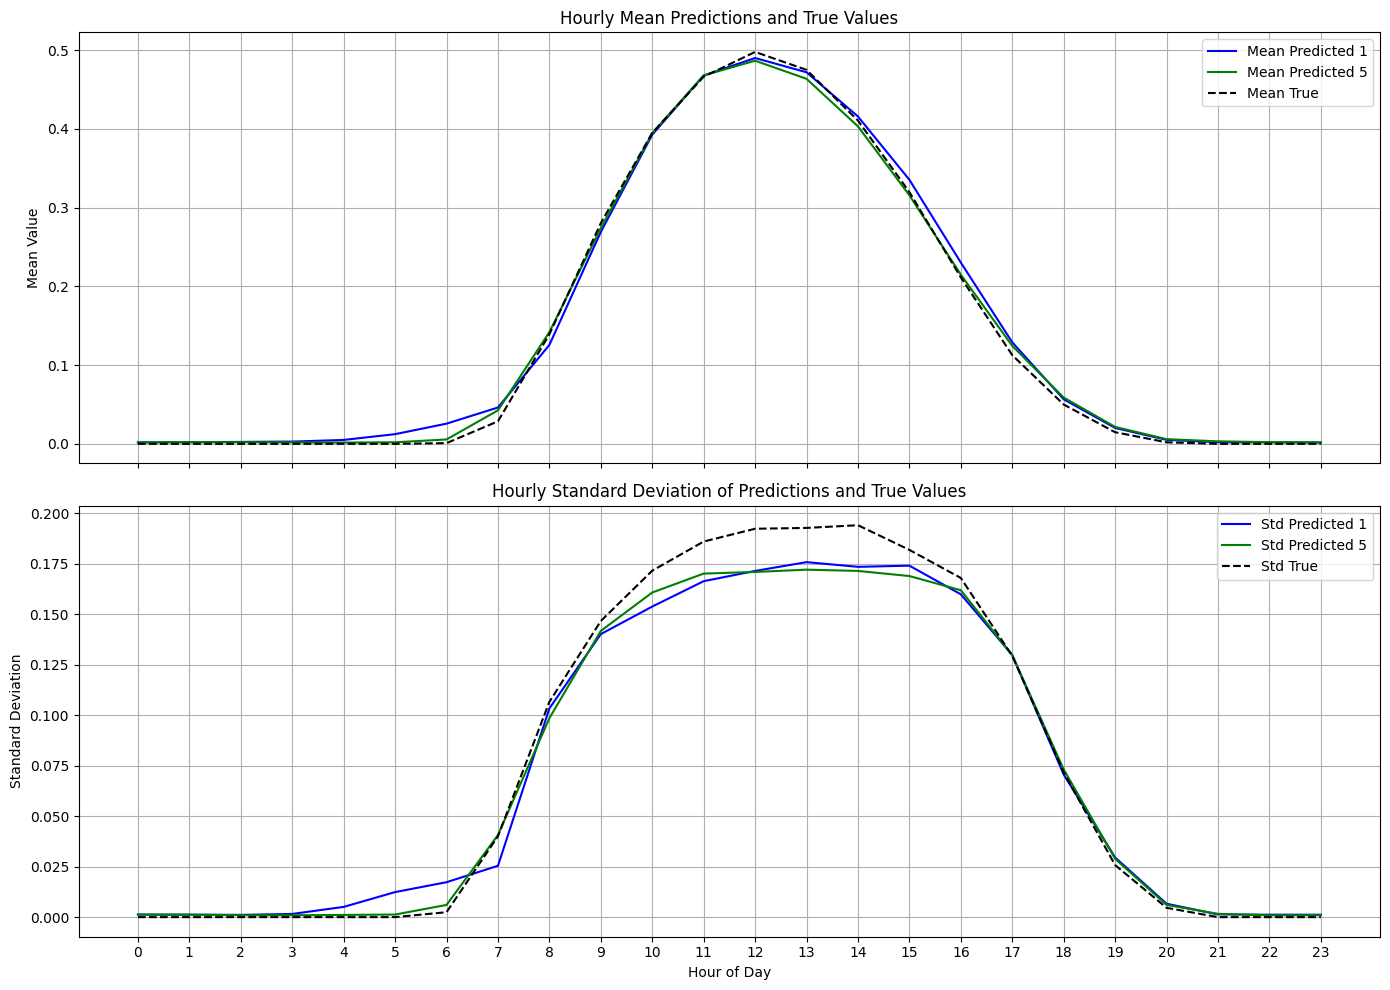

In [884]:
fig, axs = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Plot hourly means
axs[0].plot(hourly_stats_all.index, hourly_stats_all["Mean_Predicted_1"], label="Mean Predicted 1", color="blue")
axs[0].plot(hourly_stats_all.index, hourly_stats_all["Mean_Predicted_5"], label="Mean Predicted 5", color="green")
axs[0].plot(hourly_stats_all.index, hourly_stats_all["Mean_True"], label="Mean True", color="black", linestyle="--")
axs[0].set_title("Hourly Mean Predictions and True Values")
axs[0].set_ylabel("Mean Value")
axs[0].legend()
axs[0].grid(True)

# Plot hourly standard deviations
axs[1].plot(hourly_stats_all.index, hourly_stats_all["Std_Predicted_1"], label="Std Predicted 1", color="blue")
axs[1].plot(hourly_stats_all.index, hourly_stats_all["Std_Predicted_5"], label="Std Predicted 5", color="green")
axs[1].plot(hourly_stats_all.index, hourly_stats_all["Std_True"], label="Std True", color="black", linestyle="--")
axs[1].set_title("Hourly Standard Deviation of Predictions and True Values")
axs[1].set_xlabel("Hour of Day")
axs[1].set_ylabel("Standard Deviation")
axs[1].set_xticks(range(24))
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()


In [885]:
data.iloc[-7247:].index

DatetimeIndex(['2023-06-11 01:00:00', '2023-06-11 02:00:00',
               '2023-06-11 03:00:00', '2023-06-11 04:00:00',
               '2023-06-11 05:00:00', '2023-06-11 06:00:00',
               '2023-06-11 07:00:00', '2023-06-11 08:00:00',
               '2023-06-11 09:00:00', '2023-06-11 10:00:00',
               ...
               '2024-04-07 14:00:00', '2024-04-07 15:00:00',
               '2024-04-07 16:00:00', '2024-04-07 17:00:00',
               '2024-04-07 18:00:00', '2024-04-07 19:00:00',
               '2024-04-07 20:00:00', '2024-04-07 21:00:00',
               '2024-04-07 22:00:00', '2024-04-07 23:00:00'],
              dtype='datetime64[ns]', name='time', length=7247, freq=None)

In [886]:
merged_df
data = data.loc[merged_df.index] 

merged_df["cloudcover"] = data["cloudcover"]
#adding cloud coverage in the data frame

In [887]:
merged_df

,Predicted_1,True,Predicted_5,cloudcover
time,,,,
2023-06-11 02:00:00,0.0021,0.0000,0.0027,100
2023-06-11 03:00:00,0.0015,0.0000,0.0025,100
2023-06-11 04:00:00,0.0024,0.0000,0.0014,99
2023-06-11 05:00:00,0.0032,0.0000,0.0034,100
2023-06-11 06:00:00,0.0048,0.0039,0.0143,99
...,...,...,...,...
2024-04-07 19:00:00,0.0227,0.0007,0.0262,60
2024-04-07 20:00:00,0.0059,0.0000,0.0108,37
2024-04-07 21:00:00,0.0015,0.0000,0.0037,8


In [888]:
merged_df["date"] = merged_df.index.date

high_var_dates = pd.to_datetime(high_variation_days["Date"]).dt.date  

high_var_df = merged_df[merged_df["date"].isin(high_var_dates)].copy()
high_var_df


,Predicted_1,True,Predicted_5,cloudcover,date
time,,,,,
2023-06-14 00:00:00,0.0022,0.0000,0.0040,97,2023-06-14
2023-06-14 01:00:00,0.0032,0.0000,0.0029,99,2023-06-14
2023-06-14 02:00:00,0.0038,0.0000,0.0026,98,2023-06-14
2023-06-14 03:00:00,0.0026,0.0000,0.0027,100,2023-06-14
2023-06-14 04:00:00,0.0037,0.0000,0.0016,71,2023-06-14
...,...,...,...,...,...
2024-04-07 19:00:00,0.0227,0.0007,0.0262,60,2024-04-07
2024-04-07 20:00:00,0.0059,0.0000,0.0108,37,2024-04-07
2024-04-07 21:00:00,0.0015,0.0000,0.0037,8,2024-04-07


### All Hours in the Day that Have High Cloud Coverage Variation

In [889]:
high_var_df["error_1"] = abs(high_var_df["True"] - high_var_df["Predicted_1"])
high_var_df["error_5"] = abs(high_var_df["True"] - high_var_df["Predicted_5"])

In [890]:
high_var_df.shape

(2640, 7)

In [891]:
from scipy.stats import ttest_rel, wilcoxon

w_stat, p_wilcox = wilcoxon(high_var_df["error_1"], high_var_df["error_5"])
print(f"Wilcoxon test p-value: {p_wilcox}")


Wilcoxon test p-value: 2.0418337766922558e-12


In [892]:
(high_var_df["error_1"] > high_var_df["error_5"]).mean()


0.5428030303030303

### Only Non-Zero Hours In the Day with With High Cloud Coverage Variation

In [893]:
high_var_df_non0 = high_var_df[high_var_df["True"] != 0]
high_var_df_non0

,Predicted_1,True,Predicted_5,cloudcover,date,error_1,error_5
time,,,,,,,
2023-06-14 06:00:00,0.0048,0.0073,0.0137,24,2023-06-14,0.0025,0.0064
2023-06-14 07:00:00,0.0291,0.0397,0.1385,21,2023-06-14,0.0106,0.0988
2023-06-14 08:00:00,0.1768,0.0928,0.2526,16,2023-06-14,0.0840,0.1598
2023-06-14 09:00:00,0.2412,0.2441,0.2682,27,2023-06-14,0.0029,0.0241
2023-06-14 10:00:00,0.4015,0.4102,0.4452,30,2023-06-14,0.0087,0.0350
...,...,...,...,...,...,...,...
2024-04-07 15:00:00,0.4624,0.4468,0.4442,99,2024-04-07,0.0156,0.0026
2024-04-07 16:00:00,0.3689,0.3348,0.3376,100,2024-04-07,0.0341,0.0028
2024-04-07 17:00:00,0.2692,0.1064,0.1781,93,2024-04-07,0.1628,0.0717


In [894]:
high_var_df_non0["error_1"] = abs(high_var_df_non0["True"] - high_var_df_non0["Predicted_1"])
high_var_df_non0["error_5"] = abs(high_var_df_non0["True"] - high_var_df_non0["Predicted_5"])

/var/folders/gz/cwz0bhwd75x82b_jzt_7l1qw0000gn/T/ipykernel_7523/1200037586.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  high_var_df_non0["error_1"] = abs(high_var_df_non0["True"] - high_var_df_non0["Predicted_1"])
/var/folders/gz/cwz0bhwd75x82b_jzt_7l1qw0000gn/T/ipykernel_7523/1200037586.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  high_var_df_non0["error_5"] = abs(high_var_df_non0["True"] - high_var_df_non0["Predicted_5"])


In [895]:
high_var_df_non0

,Predicted_1,True,Predicted_5,cloudcover,date,error_1,error_5
time,,,,,,,
2023-06-14 06:00:00,0.0048,0.0073,0.0137,24,2023-06-14,0.0025,0.0064
2023-06-14 07:00:00,0.0291,0.0397,0.1385,21,2023-06-14,0.0106,0.0988
2023-06-14 08:00:00,0.1768,0.0928,0.2526,16,2023-06-14,0.0840,0.1598
2023-06-14 09:00:00,0.2412,0.2441,0.2682,27,2023-06-14,0.0029,0.0241
2023-06-14 10:00:00,0.4015,0.4102,0.4452,30,2023-06-14,0.0087,0.0350
...,...,...,...,...,...,...,...
2024-04-07 15:00:00,0.4624,0.4468,0.4442,99,2024-04-07,0.0156,0.0026
2024-04-07 16:00:00,0.3689,0.3348,0.3376,100,2024-04-07,0.0341,0.0028
2024-04-07 17:00:00,0.2692,0.1064,0.1781,93,2024-04-07,0.1628,0.0717


In [896]:
import scipy.stats as stats

diffs = high_var_df_non0["error_1"] - high_var_df_non0["error_5"]
stats.shapiro(diffs) 


ShapiroResult(statistic=0.9666458368301392, pvalue=2.501507992412643e-16)

In [897]:
from scipy.stats import ttest_rel, wilcoxon

w_stat, p_wilcox = wilcoxon(high_var_df_non0["error_1"], high_var_df_non0["error_5"])
print(f"Wilcoxon test p-value: {p_wilcox}")

Wilcoxon test p-value: 0.029273631293808385


In [898]:
(high_var_df_non0["error_1"] > high_var_df_non0["error_5"]).mean()


0.5168539325842697

# DataFrame of the errors from 1 Region vs 5 Regions on high variation cloud coverage days (hourly resolution)

In [899]:
high_var_df

,Predicted_1,True,Predicted_5,cloudcover,date,error_1,error_5
time,,,,,,,
2023-06-14 00:00:00,0.0022,0.0000,0.0040,97,2023-06-14,0.0022,0.0040
2023-06-14 01:00:00,0.0032,0.0000,0.0029,99,2023-06-14,0.0032,0.0029
2023-06-14 02:00:00,0.0038,0.0000,0.0026,98,2023-06-14,0.0038,0.0026
2023-06-14 03:00:00,0.0026,0.0000,0.0027,100,2023-06-14,0.0026,0.0027
2023-06-14 04:00:00,0.0037,0.0000,0.0016,71,2023-06-14,0.0037,0.0016
...,...,...,...,...,...,...,...
2024-04-07 19:00:00,0.0227,0.0007,0.0262,60,2024-04-07,0.0220,0.0255
2024-04-07 20:00:00,0.0059,0.0000,0.0108,37,2024-04-07,0.0059,0.0108
2024-04-07 21:00:00,0.0015,0.0000,0.0037,8,2024-04-07,0.0015,0.0037


# Normality test to see if we will use t-test or Wilcoxon test

In [900]:
import scipy.stats as stats

diffs = high_var_df["error_1"] - high_var_df["error_5"]
stats.shapiro(diffs) 


ShapiroResult(statistic=0.8424986004829407, pvalue=2.802596928649634e-45)

# Wilcoxon test between Errors from 1 and 5 Regions

In [901]:
from scipy.stats import ttest_rel, wilcoxon

w_stat, p_wilcox = wilcoxon(high_var_df["error_1"], high_var_df["error_5"])
print(f"Wilcoxon test p-value: {p_wilcox}")


Wilcoxon test p-value: 2.0418337766922558e-12


In [902]:
(high_var_df["error_1"] > high_var_df["error_5"]).mean()


0.5428030303030303

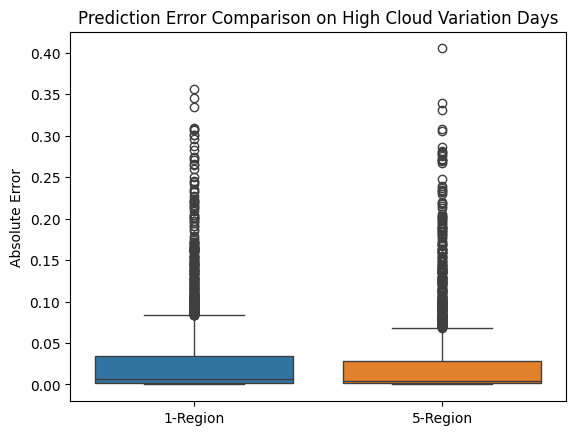

In [903]:
sns.boxplot(data=high_var_df[["error_1", "error_5"]])
plt.xticks([0, 1], ["1-Region", "5-Region"])
plt.ylabel("Absolute Error")
plt.title("Prediction Error Comparison on High Cloud Variation Days")
plt.show()

In [904]:
def detect_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series[(series < lower) | (series > upper)]

outliers_1 = detect_outliers(high_var_df["error_1"])
outliers_5 = detect_outliers(high_var_df["error_5"])

print("Outliers in 1-region model:\n", outliers_1)
print(f"The number of outliers is {outliers_1.count()}")

Outliers in 1-region model:
 time
2023-06-14 08:00:00    0.0840
2023-06-14 11:00:00    0.0979
2023-06-14 12:00:00    0.2649
2023-06-14 13:00:00    0.1274
2023-06-14 15:00:00    0.1251
                        ...  
2024-04-06 11:00:00    0.0997
2024-04-07 09:00:00    0.0967
2024-04-07 10:00:00    0.2456
2024-04-07 14:00:00    0.1975
2024-04-07 17:00:00    0.1628
Name: error_1, Length: 235, dtype: float64
The number of outliers is 235


In [905]:
print("Outliers in 5-region model:\n", outliers_5)
print(f"The number of outliers is {outliers_5.count()}")



Outliers in 5-region model:
 time
2023-06-14 07:00:00    0.0988
2023-06-14 08:00:00    0.1598
2023-06-14 11:00:00    0.1853
2023-06-14 12:00:00    0.1781
2023-06-14 13:00:00    0.1420
                        ...  
2024-04-07 09:00:00    0.1382
2024-04-07 10:00:00    0.2056
2024-04-07 13:00:00    0.0717
2024-04-07 14:00:00    0.1541
2024-04-07 17:00:00    0.0717
Name: error_5, Length: 279, dtype: float64
The number of outliers is 279


In [906]:
var_thresholds = [10, 15, 20, 25, 30, 35, 40]

data.index = pd.to_datetime(data.index)

cloudcover_data_recent = data.iloc[-7247:]["cloudcover"]

cloudcover_std_by_day = cloudcover_data_recent.groupby(cloudcover_data_recent.index.date).std()

cloudcover_std_df = cloudcover_std_by_day.reset_index()
cloudcover_std_df.columns = ["Date", "CloudCover_Std"]

high_variation_days_dict = {}

for threshold in var_thresholds:
    high_variation_days = cloudcover_std_df[cloudcover_std_df["CloudCover_Std"] > threshold]
    high_variation_days_dict[f"high_variation_days_{threshold}"] = high_variation_days

print("High variation days for threshold 10:\n", high_variation_days_dict["high_variation_days_10"])


High variation days for threshold 10:
            Date  CloudCover_Std
0    2023-06-11       17.696638
1    2023-06-12       19.943943
2    2023-06-13       26.834301
3    2023-06-14       33.643485
5    2023-06-16       14.652435
..          ...             ...
297  2024-04-03       44.229945
298  2024-04-04       11.956140
299  2024-04-05       21.003752
300  2024-04-06       40.545912
301  2024-04-07       32.410300

[221 rows x 2 columns]


In [907]:
for threshold in var_thresholds:
    print(f"{threshold}% threshold -> {len(high_variation_days_dict[f'high_variation_days_{threshold}'])} days")


10% threshold -> 221 days
15% threshold -> 191 days
20% threshold -> 167 days
25% threshold -> 144 days
30% threshold -> 110 days
35% threshold -> 75 days
40% threshold -> 34 days


In [908]:
high_variation_days_30 = high_variation_days_dict["high_variation_days_40"]

In [909]:
df_1 = pd.read_csv("/Users/iraklisdimitriadis/Documents/Μαθήματα-Σημειώσεις Data Science/Dissertation/Code/Region1_Predictions.csv", index_col=0, parse_dates=True)
df_2 = pd.read_csv("/Users/iraklisdimitriadis/Documents/Μαθήματα-Σημειώσεις Data Science/Dissertation/Code/Region5_Predictions.csv", index_col=0, parse_dates=True)

df_1 = df_1.rename(columns={"Predicted": "Predicted_1", "True": "True_1"})
df_2 = df_2.rename(columns={"Predicted": "Predicted_5", "True": "True_5"})

In [910]:
merged_df = pd.merge(df_1, df_2, left_index=True, right_index=True)

merged_df = merged_df.drop(columns=["True_5"]).rename(columns={"True_1": "True"})

merged_df

,Predicted_1,True,Predicted_5
time,,,
2023-06-11 02:00:00,0.0021,0.0000,0.0027
2023-06-11 03:00:00,0.0015,0.0000,0.0025
2023-06-11 04:00:00,0.0024,0.0000,0.0014
2023-06-11 05:00:00,0.0032,0.0000,0.0034
2023-06-11 06:00:00,0.0048,0.0039,0.0143
...,...,...,...
2024-04-07 19:00:00,0.0227,0.0007,0.0262
2024-04-07 20:00:00,0.0059,0.0000,0.0108
2024-04-07 21:00:00,0.0015,0.0000,0.0037


In [911]:
merged_df
data = data.loc[merged_df.index] 

merged_df["cloudcover"] = data["cloudcover"]
merged_df
#adding cloud coverage in the data frame

,Predicted_1,True,Predicted_5,cloudcover
time,,,,
2023-06-11 02:00:00,0.0021,0.0000,0.0027,100
2023-06-11 03:00:00,0.0015,0.0000,0.0025,100
2023-06-11 04:00:00,0.0024,0.0000,0.0014,99
2023-06-11 05:00:00,0.0032,0.0000,0.0034,100
2023-06-11 06:00:00,0.0048,0.0039,0.0143,99
...,...,...,...,...
2024-04-07 19:00:00,0.0227,0.0007,0.0262,60
2024-04-07 20:00:00,0.0059,0.0000,0.0108,37
2024-04-07 21:00:00,0.0015,0.0000,0.0037,8


In [912]:
merged_df["date"] = merged_df.index.date

high_var_dates = pd.to_datetime(high_variation_days_30["Date"]).dt.date  

high_var_df = merged_df[merged_df["date"].isin(high_var_dates)].copy()

high_var_df

,Predicted_1,True,Predicted_5,cloudcover,date
time,,,,,
2023-06-23 00:00:00,0.0002,0.0000,0.0022,9,2023-06-23
2023-06-23 01:00:00,0.0009,0.0000,0.0024,2,2023-06-23
2023-06-23 02:00:00,0.0022,0.0000,0.0007,0,2023-06-23
2023-06-23 03:00:00,0.0031,0.0000,0.0021,0,2023-06-23
2023-06-23 04:00:00,0.0028,0.0000,0.0008,0,2023-06-23
...,...,...,...,...,...
2024-04-06 19:00:00,0.0405,0.0225,0.0528,95,2024-04-06
2024-04-06 20:00:00,0.0039,0.0000,0.0156,91,2024-04-06
2024-04-06 21:00:00,0.0026,0.0000,0.0035,98,2024-04-06


In [913]:
from sklearn.metrics import r2_score, mean_squared_error


r2_score(high_var_df["Predicted_5"], high_var_df["True"]), r2_score(high_var_df["Predicted_1"], high_var_df["True"])

(0.9366274905094089, 0.9255565899568468)

In [914]:
# Select the columns to analyze
cols = ["Predicted_1", "Predicted_5", "True"]

# Group by hour extracted from the datetime index
hourly_mean = high_var_df.groupby(high_var_df.index.hour)[cols].mean()
hourly_std = high_var_df.groupby(high_var_df.index.hour)[cols].std()

# Combine and rename columns
hourly_stats = pd.concat([hourly_mean, hourly_std], axis=1)
hourly_stats.columns = [
    "Mean_Predicted_1", "Mean_Predicted_5", "Mean_True",
    "Std_Predicted_1", "Std_Predicted_5", "Std_True"
]

In [915]:
hourly_stats

,Mean_Predicted_1,Mean_Predicted_5,Mean_True,Std_Predicted_1,Std_Predicted_5,Std_True
time,,,,,,
0,0.002265,0.001776,0.000000,0.001304,0.000891,0.000000
1,0.002209,0.001897,0.000000,0.000959,0.000991,0.000000
2,0.002638,0.001932,0.000000,0.001111,0.000726,0.000000
3,0.003044,0.001797,0.000000,0.001288,0.000712,0.000000
4,0.006156,0.001682,0.000000,0.007038,0.000979,0.000000
5,0.015100,0.001826,0.000000,0.012380,0.001006,0.000000
6,0.028174,0.004591,0.001085,0.016672,0.003423,0.003144
7,0.042924,0.035232,0.032197,0.020984,0.033860,0.055215
8,0.121426,0.141647,0.143474,0.115169,0.111117,0.116437


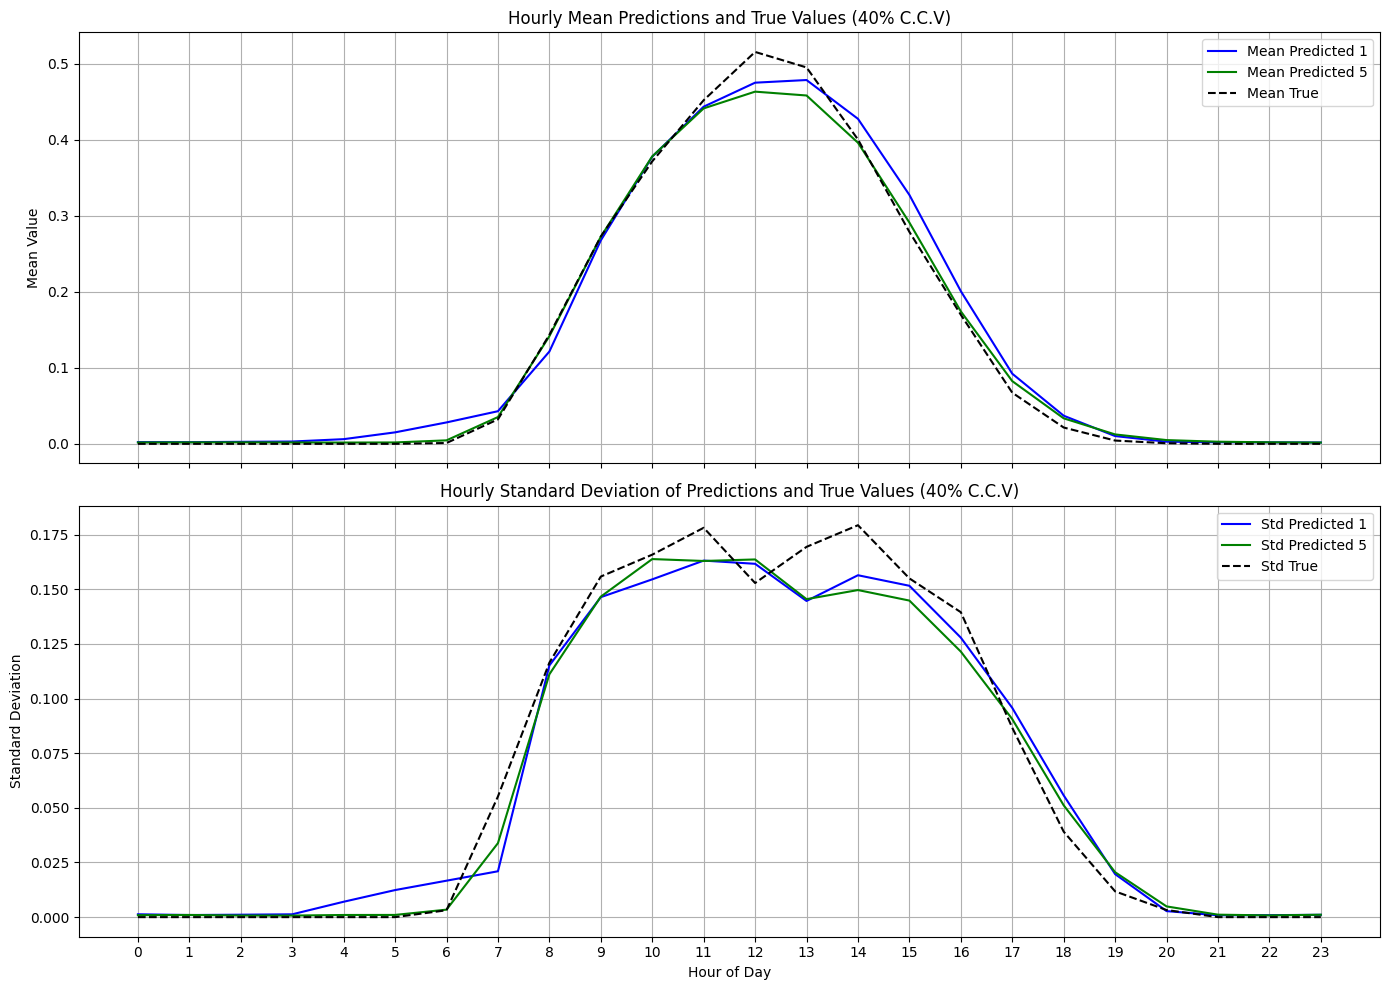

In [916]:
fig, axs = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Plot hourly means
axs[0].plot(hourly_stats.index, hourly_stats["Mean_Predicted_1"], label="Mean Predicted 1", color="blue")
axs[0].plot(hourly_stats.index, hourly_stats["Mean_Predicted_5"], label="Mean Predicted 5", color="green")
axs[0].plot(hourly_stats.index, hourly_stats["Mean_True"], label="Mean True", color="black", linestyle="--")
axs[0].set_title("Hourly Mean Predictions and True Values (40% C.C.V)")
axs[0].set_ylabel("Mean Value")
axs[0].legend()
axs[0].grid(True)

# Plot hourly standard deviations
axs[1].plot(hourly_stats.index, hourly_stats["Std_Predicted_1"], label="Std Predicted 1", color="blue")
axs[1].plot(hourly_stats.index, hourly_stats["Std_Predicted_5"], label="Std Predicted 5", color="green")
axs[1].plot(hourly_stats.index, hourly_stats["Std_True"], label="Std True", color="black", linestyle="--")
axs[1].set_title("Hourly Standard Deviation of Predictions and True Values (40% C.C.V)")
axs[1].set_xlabel("Hour of Day")
axs[1].set_ylabel("Standard Deviation")
axs[1].set_xticks(range(24))
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()


### Comparison Between 5 to 40 % Cloud Coverage Variation 

In [917]:
thresholds = [10, 15, 20, 25, 30, 35, 40]

summary_data = []

for threshold in thresholds:
    high_var_dates = pd.to_datetime(high_variation_days_dict[f"high_variation_days_{threshold}"]["Date"]).dt.date

    high_var_df = merged_df[merged_df["date"].isin(high_var_dates)].copy()  # Use .isin() on the 'date' column

    hourly_mean = high_var_df.groupby(high_var_df.index.hour)[cols].mean()
    hourly_std = high_var_df.groupby(high_var_df.index.hour)[cols].std()

    hourly_stats = pd.concat([hourly_mean, hourly_std], axis=1)
    hourly_stats.columns = [
        "Mean_Predicted_1", "Mean_Predicted_5", "Mean_True",
        "Std_Predicted_1", "Std_Predicted_5", "Std_True"
    ]

    summary_data.append({
        "Threshold": threshold,
        "Avg_Mean_Pred_1": hourly_stats["Mean_Predicted_1"].mean(),
        "Avg_Mean_Pred_5": hourly_stats["Mean_Predicted_5"].mean(),
        "Avg_Mean_True": hourly_stats["Mean_True"].mean(),
        "Avg_Std_Pred_1": hourly_stats["Std_Predicted_1"].mean(),
        "Avg_Std_Pred_5": hourly_stats["Std_Predicted_5"].mean(),
        "Avg_Std_True": hourly_stats["Std_True"].mean()
    })

summary_df = pd.DataFrame(summary_data)


In [918]:
summary_data

[{'Threshold': 10,
  'Avg_Mean_Pred_1': 0.14103428788848224,
  'Avg_Mean_Pred_5': 0.1374544465036519,
  'Avg_Mean_True': 0.1362506221719457,
  'Avg_Std_Pred_1': 0.06766576439371116,
  'Avg_Std_Pred_5': 0.06683903971740791,
  'Avg_Std_True': 0.07151246927479075},
 {'Threshold': 15,
  'Avg_Mean_Pred_1': 0.13820294569299493,
  'Avg_Mean_Pred_5': 0.13426608511491478,
  'Avg_Mean_True': 0.1334930410122164,
  'Avg_Std_Pred_1': 0.06498917952053264,
  'Avg_Std_Pred_5': 0.06420685227775733,
  'Avg_Std_True': 0.0689470435445065},
 {'Threshold': 20,
  'Avg_Mean_Pred_1': 0.1371622005308908,
  'Avg_Mean_Pred_5': 0.13294266466843785,
  'Avg_Mean_True': 0.1328435878243513,
  'Avg_Std_Pred_1': 0.06364958067366898,
  'Avg_Std_Pred_5': 0.0629534221754046,
  'Avg_Std_True': 0.06728114707094278},
 {'Threshold': 25,
  'Avg_Mean_Pred_1': 0.1384902777325515,
  'Avg_Mean_Pred_5': 0.13416310767508285,
  'Avg_Mean_True': 0.13390468749999998,
  'Avg_Std_Pred_1': 0.06237122335064748,
  'Avg_Std_Pred_5': 0.0615365

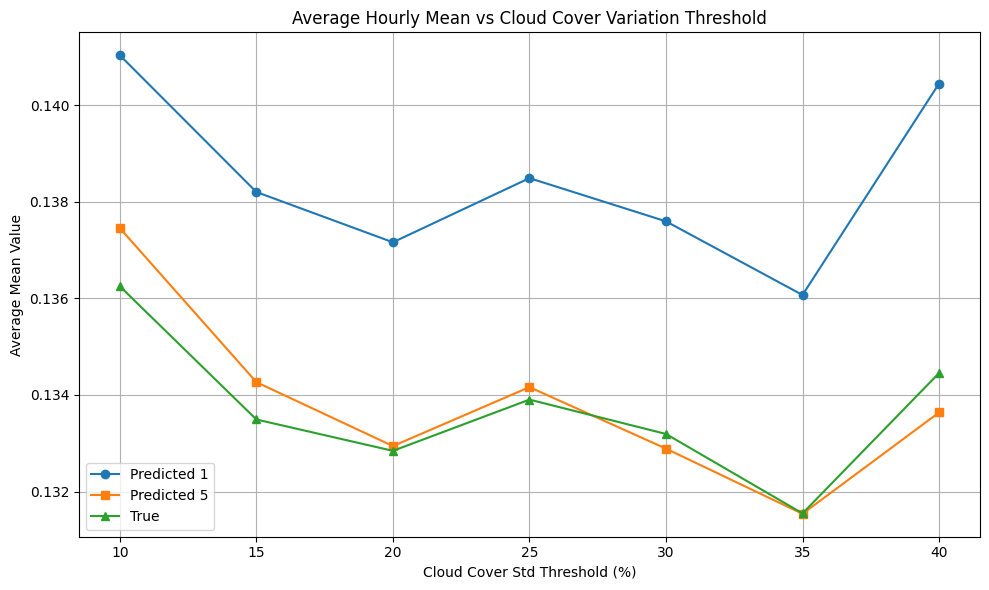

In [919]:
plt.figure(figsize=(10, 6))
plt.plot(summary_df["Threshold"], summary_df["Avg_Mean_Pred_1"], label="Predicted 1", marker='o')
plt.plot(summary_df["Threshold"], summary_df["Avg_Mean_Pred_5"], label="Predicted 5", marker='s')
plt.plot(summary_df["Threshold"], summary_df["Avg_Mean_True"], label="True", marker='^')
plt.title("Average Hourly Mean vs Cloud Cover Variation Threshold")
plt.xlabel("Cloud Cover Std Threshold (%)")
plt.ylabel("Average Mean Value")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [920]:
from sklearn.metrics import r2_score, mean_squared_error

metrics = []

for threshold in var_thresholds:
    high_var_dates = pd.to_datetime(high_variation_days_dict[f"high_variation_days_{threshold}"]["Date"]).dt.date
    high_var_df = merged_df[merged_df["date"].isin(high_var_dates)].copy()
    
    y_true = high_var_df["True"]
    y_pred_1 = high_var_df["Predicted_1"]
    y_pred_5 = high_var_df["Predicted_5"]
    
    metrics.append({
        "Threshold": threshold,
        "R2_1": r2_score(y_true, y_pred_1),
        "MSE_1": mean_squared_error(y_true, y_pred_1),
        "R2_5": r2_score(y_true, y_pred_5),
        "MSE_5": mean_squared_error(y_true, y_pred_5)
    })

metrics_df = pd.DataFrame(metrics)


In [921]:
high_variation_days_dict["high_variation_days_30"]

,Date,CloudCover_Std
3,2023-06-14,33.643485
7,2023-06-18,37.421197
10,2023-06-21,32.127802
12,2023-06-23,41.686459
13,2023-06-24,39.546340
...,...,...
294,2024-03-31,35.039703
296,2024-04-02,38.694174
297,2024-04-03,44.229945
300,2024-04-06,40.545912


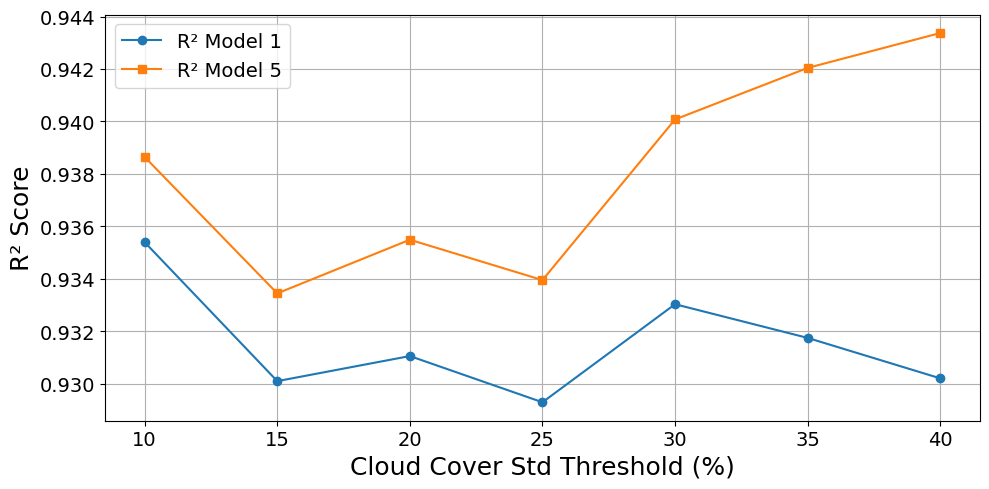

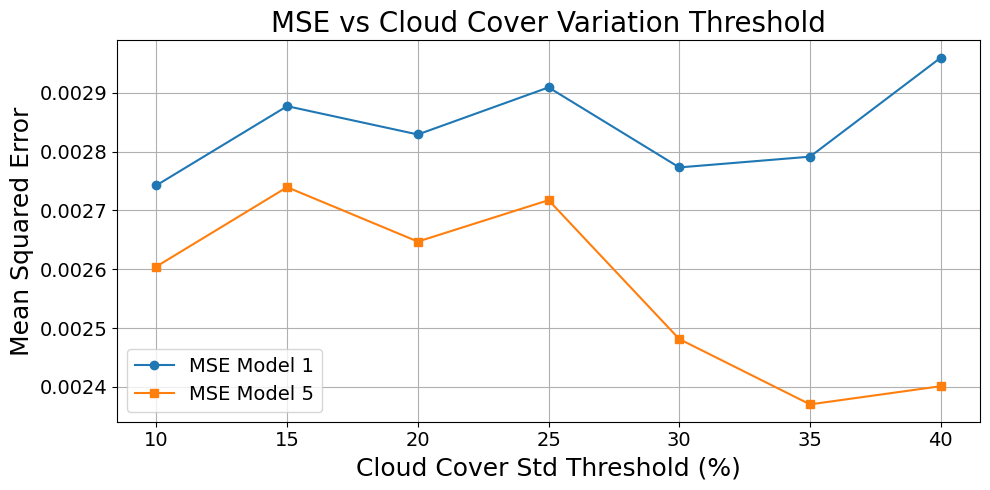

In [922]:
# R² plot
plt.figure(figsize=(10, 5))
plt.plot(metrics_df["Threshold"], metrics_df["R2_1"], label="R² Model 1", marker='o')
plt.plot(metrics_df["Threshold"], metrics_df["R2_5"], label="R² Model 5", marker='s')
#plt.title("R² Score vs Cloud Cover Variation Threshold", fontsize=20)
plt.xlabel("Cloud Cover Std Threshold (%)", fontsize=18)
plt.ylabel("R² Score", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

# MSE plot
plt.figure(figsize=(10, 5))
plt.plot(metrics_df["Threshold"], metrics_df["MSE_1"], label="MSE Model 1", marker='o')
plt.plot(metrics_df["Threshold"], metrics_df["MSE_5"], label="MSE Model 5", marker='s')
plt.title("MSE vs Cloud Cover Variation Threshold", fontsize=20)
plt.xlabel("Cloud Cover Std Threshold (%)", fontsize=18)
plt.ylabel("Mean Squared Error", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()
